# 08 — MLP Feature Ablation Study with Non-Overlapping Test Evaluation

This notebook repeats the MLP feature ablation study for the sequence-to-sequence battery surrogate, but evaluates the final test performance using **non-overlapping forecast blocks**.

Important design:
- Training data still uses the original overlapping stride-5 windows.
- Validation also uses the original prepared validation windows for early stopping.
- Test reporting adds a non-overlapping evaluation by selecting every `H / STRIDE` test window.
- With `H = 50` and `STRIDE = 5`, every 10th test window is selected.


In [1]:
from pathlib import Path
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0


In [2]:
# Reproducibility

SEED = 63

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [ ]:
# Paths and fixed sequence settings

PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results_nonoverlap")
FIGURES_DIR = Path("../figures_nonoverlap")
MODELS_DIR = Path("../models_nonoverlap")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_LENGTH = 50
PREDICTION_HORIZON = 50
STRIDE = 5

# Non-overlapping test evaluation setting.
# The prepared dataset uses STRIDE=5. Since horizon=50, selecting every 10th test window
# gives approximately non-overlapping 50-step forecast blocks.

TEST_STRIDE = PREDICTION_HORIZON

if TEST_STRIDE % STRIDE != 0:
    raise ValueError("TEST_STRIDE must be divisible by STRIDE.")

TEST_STRIDE_FACTOR = TEST_STRIDE // STRIDE

# Using the full physics dataset, then subset columns for each ablation.

NPZ_PATH = PROCESSED_DIR / f"seq2seq_physics_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}.npz"
SCALER_PATH = PROCESSED_DIR / f"seq2seq_physics_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}_scaler.json"

print("NPZ path:", NPZ_PATH)
print("Scaler path:", SCALER_PATH)
print("TEST_STRIDE:", TEST_STRIDE)
print("TEST_STRIDE_FACTOR:", TEST_STRIDE_FACTOR)


NPZ path: ../data/processed/seq2seq_physics_L50_H50_S5.npz
Scaler path: ../data/processed/seq2seq_physics_L50_H50_S5_scaler.json
TEST_STRIDE: 50
TEST_STRIDE_FACTOR: 10


In [ ]:
# Loading full physics processed dataset

data = np.load(NPZ_PATH)

X_train_full = data["X_train"]
Y_train = data["Y_train"]

X_val_full = data["X_val"]
Y_val = data["Y_val"]

X_test_full = data["X_test"]
Y_test = data["Y_test"]

print("X_train_full:", X_train_full.shape, "Y_train:", Y_train.shape)
print("X_val_full:", X_val_full.shape, "Y_val:", Y_val.shape)
print("X_test_full:", X_test_full.shape, "Y_test:", Y_test.shape)

with open(SCALER_PATH, "r") as f:
    scaler = json.load(f)

full_input_cols = scaler["input_cols"]
output_cols = scaler["output_cols"]

y_mean = np.array(scaler["y_mean"], dtype=np.float32)
y_std = np.array(scaler["y_std"], dtype=np.float32)

print("Full input columns:")
for i, col in enumerate(full_input_cols):
    print(i, col)

print("\nOutput columns:")
for i, col in enumerate(output_cols):
    print(i, col)

X_train_full: (233957, 50, 4) Y_train: (233957, 50, 3)
X_val_full: (56993, 50, 4) Y_val: (56993, 50, 3)
X_test_full: (49033, 50, 4) Y_test: (49033, 50, 3)
Full input columns:
0 Current [A]
1 Terminal voltage [V]
2 Cumulative charge [A.s]
3 Sqrt cumulative charge [sqrt(A.s)]

Output columns:
0 SEI growth rate [nm/s]
1 Negative SEI thickness [nm]
2 Cell temperature [K]


## Feature ablation settings

The processed physics dataset has four scaled input columns:

```text
0: Current [A]
1: Terminal voltage [V]
2: Cumulative charge [A.s]
3: Sqrt cumulative charge [sqrt(A.s)]
```

Each ablation setting selects a subset of these columns. Training remains overlapping; the non-overlapping change is applied only at test evaluation.


In [5]:
ABLATION_FEATURE_SETS = {
    "current_voltage": {
        "label": "Current + Voltage",
        "indices": [0, 1],
    },
    "current_voltage_cumcharge": {
        "label": "Current + Voltage + Cumulative charge",
        "indices": [0, 1, 2],
    },
    "current_voltage_sqrtcumcharge": {
        "label": "Current + Voltage + Sqrt cumulative charge",
        "indices": [0, 1, 3],
    },
    "current_voltage_cumcharge_sqrtcumcharge": {
        "label": "Current + Voltage + Cumulative charge + Sqrt cumulative charge",
        "indices": [0, 1, 2, 3],
    },
}

for key, cfg in ABLATION_FEATURE_SETS.items():
    print(key, "->", cfg["label"], "| indices:", cfg["indices"])

current_voltage -> Current + Voltage | indices: [0, 1]
current_voltage_cumcharge -> Current + Voltage + Cumulative charge | indices: [0, 1, 2]
current_voltage_sqrtcumcharge -> Current + Voltage + Sqrt cumulative charge | indices: [0, 1, 3]
current_voltage_cumcharge_sqrtcumcharge -> Current + Voltage + Cumulative charge + Sqrt cumulative charge | indices: [0, 1, 2, 3]


In [6]:
class Seq2SeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


class MLPDirectSeq2Seq(nn.Module):
    def __init__(self, input_length, input_dim, output_dim, horizon, dropout=0.2):
        super().__init__()

        self.output_dim = output_dim
        self.horizon = horizon

        flat_dim = input_length * input_dim

        self.network = nn.Sequential(
            nn.Linear(flat_dim, 512),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(128, horizon * output_dim),
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = x.reshape(batch_size, -1)
        out = self.network(x)
        out = out.view(batch_size, self.horizon, self.output_dim)
        return out

In [7]:
# Training configuration

BATCH_SIZE = 256
EPOCHS = 50
LEARNING_RATE = 1e-3
PATIENCE = 8
DROPOUT = 0.2

criterion = nn.MSELoss()

print("Training setup:")
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Patience:", PATIENCE)

Training setup:
Batch size: 256
Epochs: 50
Learning rate: 0.001
Patience: 8


In [8]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            preds = model(X_batch)
            loss = criterion(preds, Y_batch)

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


def predict(model, loader):
    model.eval()

    preds_all = []
    targets_all = []

    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()

            preds_all.append(preds)
            targets_all.append(Y_batch.numpy())

    preds_all = np.concatenate(preds_all, axis=0)
    targets_all = np.concatenate(targets_all, axis=0)

    return preds_all, targets_all


def inverse_transform_y(y_scaled):
    return y_scaled * y_std.reshape(1, 1, -1) + y_mean.reshape(1, 1, -1)

In [9]:
def compute_metrics(y_true, y_pred, output_cols):
    rows = []
    eps = 1e-12

    for i, col in enumerate(output_cols):
        yt = y_true[:, :, i].reshape(-1)
        yp = y_pred[:, :, i].reshape(-1)

        error = yp - yt

        mse = np.mean(error ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(error))

        true_std = np.std(yt)
        true_mean_abs = np.mean(np.abs(yt))

        nmae_std = mae / (true_std + eps)
        nrmse_std = rmse / (true_std + eps)
        relative_mae = mae / (true_mean_abs + eps)

        ss_res = np.sum((yt - yp) ** 2)
        ss_tot = np.sum((yt - np.mean(yt)) ** 2)
        r2 = 1 - ss_res / (ss_tot + eps)

        rows.append({
            "output": col,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "NMAE_std": nmae_std,
            "NRMSE_std": nrmse_std,
            "Relative_MAE_mean_abs": relative_mae,
            "R2": r2,
            "true_mean_abs": true_mean_abs,
            "true_std": true_std,
        })

    return pd.DataFrame(rows)


def physical_violation_check(pred_test, output_cols):
    rows = []

    checked_outputs = [
        "SEI growth rate [nm/s]",
        "Negative SEI thickness [nm]",
        "Cell temperature [K]",
    ]

    for col in checked_outputs:
        idx = output_cols.index(col)
        values = pred_test[:, :, idx]

        total_count = values.size
        negative_count = np.sum(values < 0)
        negative_percent = 100 * negative_count / total_count

        rows.append({
            "output": col,
            "negative_count": int(negative_count),
            "total_count": int(total_count),
            "negative_percent": negative_percent,
            "minimum_prediction": float(np.min(values)),
        })

    return pd.DataFrame(rows)


def horizon_wise_normalized_mae(y_true, y_pred, output_cols):
    rows = []
    eps = 1e-12

    for i, col in enumerate(output_cols):
        true_std = np.std(y_true[:, :, i].reshape(-1))

        for h in range(y_true.shape[1]):
            mae = np.mean(np.abs(y_true[:, h, i] - y_pred[:, h, i]))
            nmae = mae / (true_std + eps)

            rows.append({
                "horizon_step": h + 1,
                "output": col,
                "NMAE_std": nmae,
            })

    return pd.DataFrame(rows)

In [ ]:
def train_one_ablation(feature_key, feature_label, feature_indices):
    print("\n" + "=" * 80)
    print("Ablation:", feature_label)
    print("=" * 80)

    input_cols = [full_input_cols[i] for i in feature_indices]

    # Training/validation/test arrays are loaded from the original stride-5 dataset.
    # Therefore, training is still overlapping.
    X_train = X_train_full[:, :, feature_indices]
    X_val = X_val_full[:, :, feature_indices]
    X_test = X_test_full[:, :, feature_indices]

    print("Input columns:", input_cols)
    print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
    print("X_val:", X_val.shape, "Y_val:", Y_val.shape)
    print("X_test overlapping:", X_test.shape, "Y_test overlapping:", Y_test.shape)

    train_dataset = Seq2SeqDataset(X_train, Y_train)
    val_dataset = Seq2SeqDataset(X_val, Y_val)
    test_dataset = Seq2SeqDataset(X_test, Y_test)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    input_dim = X_train.shape[-1]
    output_dim = Y_train.shape[-1]
    horizon = Y_train.shape[1]

    model = MLPDirectSeq2Seq(
        input_length=INPUT_LENGTH,
        input_dim=input_dim,
        output_dim=output_dim,
        horizon=horizon,
        dropout=DROPOUT,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    model_name = f"mlp_ablation_nonoverlap_{feature_key}_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}"
    best_model_path = MODELS_DIR / f"{model_name}.pt"

    history = []
    best_val_loss = float("inf")
    best_epoch = -1
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss = run_epoch(model, val_loader, optimizer=None)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "learning_rate": current_lr,
            "feature_key": feature_key,
            "feature_label": feature_label,
            "model_name": model_name,
        })

        print(
            f"Epoch {epoch:03d} | "
            f"train={train_loss:.6f} | "
            f"val={val_loss:.6f} | "
            f"lr={current_lr:.2e}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "input_dim": input_dim,
                "output_dim": output_dim,
                "horizon": horizon,
                "input_cols": input_cols,
                "output_cols": output_cols,
                "feature_key": feature_key,
                "feature_label": feature_label,
                "feature_indices": feature_indices,
                "input_length": INPUT_LENGTH,
                "prediction_horizon": PREDICTION_HORIZON,
                "stride": STRIDE,
                "test_stride": TEST_STRIDE,
                "test_stride_factor": TEST_STRIDE_FACTOR,
                "best_epoch": best_epoch,
                "best_val_loss": best_val_loss,
            }, best_model_path)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    elapsed = time.time() - start_time

    print("Best epoch:", best_epoch)
    print("Best val loss:", best_val_loss)
    print(f"Training time: {elapsed:.2f} seconds")

    # Load best model
    checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    
    # Standard overlapping validation/test evaluation
    
    pred_val_scaled, true_val_scaled = predict(model, val_loader)
    pred_test_scaled, true_test_scaled = predict(model, test_loader)

    pred_val = inverse_transform_y(pred_val_scaled)
    true_val = inverse_transform_y(true_val_scaled)

    pred_test = inverse_transform_y(pred_test_scaled)
    true_test = inverse_transform_y(true_test_scaled)

    val_metrics = compute_metrics(true_val, pred_val, output_cols)
    test_metrics = compute_metrics(true_test, pred_test, output_cols)

    val_metrics["split"] = "val"
    test_metrics["split"] = "test_overlap"

    
    # Non-overlapping test evaluation
    
    X_test_blocks = X_test[::TEST_STRIDE_FACTOR]
    Y_test_blocks = Y_test[::TEST_STRIDE_FACTOR]

    print("X_test non-overlap:", X_test_blocks.shape, "Y_test non-overlap:", Y_test_blocks.shape)

    block_test_loader = DataLoader(
        Seq2SeqDataset(X_test_blocks, Y_test_blocks),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    pred_blocks_scaled, true_blocks_scaled = predict(model, block_test_loader)

    pred_blocks = inverse_transform_y(pred_blocks_scaled)
    true_blocks = inverse_transform_y(true_blocks_scaled)

    nonoverlap_metrics = compute_metrics(true_blocks, pred_blocks, output_cols)
    nonoverlap_metrics["split"] = f"test_nonoverlap_stride{TEST_STRIDE}"

    metrics_df = pd.concat(
        [val_metrics, test_metrics, nonoverlap_metrics],
        ignore_index=True
    )

    metrics_df["feature_key"] = feature_key
    metrics_df["feature_label"] = feature_label
    metrics_df["model_name"] = model_name
    metrics_df["input_dim"] = input_dim
    metrics_df["best_epoch"] = best_epoch
    metrics_df["best_val_loss"] = best_val_loss
    metrics_df["training_time_seconds"] = elapsed
    metrics_df["test_stride"] = TEST_STRIDE
    metrics_df["test_stride_factor"] = TEST_STRIDE_FACTOR

    metrics_path = RESULTS_DIR / f"{model_name}_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)

    history_df = pd.DataFrame(history)
    history_path = RESULTS_DIR / f"{model_name}_history.csv"
    history_df.to_csv(history_path, index=False)

    # Physical violations on non-overlapping predictions
    violations_df = physical_violation_check(pred_blocks, output_cols)
    violations_df["split"] = f"test_nonoverlap_stride{TEST_STRIDE}"
    violations_df["feature_key"] = feature_key
    violations_df["feature_label"] = feature_label
    violations_df["model_name"] = model_name
    violations_path = RESULTS_DIR / f"{model_name}_nonoverlap_physical_violations.csv"
    violations_df.to_csv(violations_path, index=False)

    # Horizon-wise NMAE on non-overlapping predictions
    horizon_nmae_df = horizon_wise_normalized_mae(true_blocks, pred_blocks, output_cols)
    horizon_nmae_df["split"] = f"test_nonoverlap_stride{TEST_STRIDE}"
    horizon_nmae_df["feature_key"] = feature_key
    horizon_nmae_df["feature_label"] = feature_label
    horizon_nmae_df["model_name"] = model_name
    horizon_nmae_path = RESULTS_DIR / f"{model_name}_nonoverlap_horizon_nmae.csv"
    horizon_nmae_df.to_csv(horizon_nmae_path, index=False)

    # Save predictions for later diagnostic plots
    np.savez_compressed(
        RESULTS_DIR / f"{model_name}_nonoverlap_test_predictions.npz",
        true_blocks=true_blocks,
        pred_blocks=pred_blocks,
        true_blocks_scaled=true_blocks_scaled,
        pred_blocks_scaled=pred_blocks_scaled,
        true_test_overlap=true_test,
        pred_test_overlap=pred_test,
        output_cols=np.array(output_cols),
        input_cols=np.array(input_cols),
        feature_key=feature_key,
        feature_label=feature_label,
        test_stride=TEST_STRIDE,
        test_stride_factor=TEST_STRIDE_FACTOR,
    )

    print("Saved metrics:", metrics_path.resolve())
    print("Saved history:", history_path.resolve())
    print("Saved non-overlap physical violations:", violations_path.resolve())
    print("Saved non-overlap horizon NMAE:", horizon_nmae_path.resolve())

    return metrics_df, history_df, violations_df, horizon_nmae_df


## Run all ablation experiments

This will train four MLP models. It may take some time because each feature setting is trained separately.

In [11]:
all_metrics = []
all_histories = []
all_violations = []
all_horizon_nmae = []

for feature_key, cfg in ABLATION_FEATURE_SETS.items():
    metrics_df, history_df, violations_df, horizon_nmae_df = train_one_ablation(
        feature_key=feature_key,
        feature_label=cfg["label"],
        feature_indices=cfg["indices"],
    )

    all_metrics.append(metrics_df)
    all_histories.append(history_df)
    all_violations.append(violations_df)
    all_horizon_nmae.append(horizon_nmae_df)

combined_metrics = pd.concat(all_metrics, ignore_index=True)
combined_histories = pd.concat(all_histories, ignore_index=True)
combined_violations = pd.concat(all_violations, ignore_index=True)
combined_horizon_nmae = pd.concat(all_horizon_nmae, ignore_index=True)

combined_metrics_path = RESULTS_DIR / f"mlp_feature_ablation_nonoverlap_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}_metrics.csv"
combined_histories_path = RESULTS_DIR / f"mlp_feature_ablation_nonoverlap_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}_histories.csv"
combined_violations_path = RESULTS_DIR / f"mlp_feature_ablation_nonoverlap_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}_physical_violations.csv"
combined_horizon_nmae_path = RESULTS_DIR / f"mlp_feature_ablation_nonoverlap_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}_horizon_nmae.csv"

combined_metrics.to_csv(combined_metrics_path, index=False)
combined_histories.to_csv(combined_histories_path, index=False)
combined_violations.to_csv(combined_violations_path, index=False)
combined_horizon_nmae.to_csv(combined_horizon_nmae_path, index=False)

print("Saved combined metrics:", combined_metrics_path.resolve())
print("Saved combined histories:", combined_histories_path.resolve())
print("Saved combined violations:", combined_violations_path.resolve())
print("Saved combined horizon NMAE:", combined_horizon_nmae_path.resolve())

combined_metrics.head()



Ablation: Current + Voltage
Input columns: ['Current [A]', 'Terminal voltage [V]']
X_train: (233957, 50, 2) Y_train: (233957, 50, 3)
X_val: (56993, 50, 2) Y_val: (56993, 50, 3)
X_test overlapping: (49033, 50, 2) Y_test overlapping: (49033, 50, 3)
Epoch 001 | train=0.288532 | val=0.356239 | lr=1.00e-03
Epoch 002 | train=0.215300 | val=0.359289 | lr=1.00e-03
Epoch 003 | train=0.200576 | val=0.335398 | lr=1.00e-03
Epoch 004 | train=0.190473 | val=0.333247 | lr=1.00e-03
Epoch 005 | train=0.185645 | val=0.345610 | lr=1.00e-03
Epoch 006 | train=0.180617 | val=0.355833 | lr=1.00e-03
Epoch 007 | train=0.176413 | val=0.333647 | lr=1.00e-03
Epoch 008 | train=0.174066 | val=0.324376 | lr=1.00e-03
Epoch 009 | train=0.171307 | val=0.330830 | lr=1.00e-03
Epoch 010 | train=0.169210 | val=0.301496 | lr=1.00e-03
Epoch 011 | train=0.166372 | val=0.356702 | lr=1.00e-03
Epoch 012 | train=0.166206 | val=0.348523 | lr=1.00e-03
Epoch 013 | train=0.164706 | val=0.357770 | lr=1.00e-03
Epoch 014 | train=0.1622

,output,MSE,RMSE,MAE,NMAE_std,NRMSE_std,Relative_MAE_mean_abs,R2,true_mean_abs,true_std,split,feature_key,feature_label,model_name,input_dim,best_epoch,best_val_loss,training_time_seconds,test_stride,test_stride_factor
0,SEI growth rate [nm/s],7.827897e-07,0.000885,0.000552,0.274600,0.440091,0.240793,0.806320,0.002293,0.002010,val,current_voltage,Current + Voltage,mlp_ablation_nonoverlap_current_voltage_L50_H5...,2,10,0.301496,85.927463,50,10
1,Negative SEI thickness [nm],5.994273e+03,77.422691,53.901287,0.509780,0.732238,0.289324,0.463828,186.300522,105.734329,val,current_voltage,Current + Voltage,mlp_ablation_nonoverlap_current_voltage_L50_H5...,2,10,0.301496,85.927463,50,10
2,Cell temperature [K],1.492431e-02,0.122165,0.047232,0.123727,0.320016,0.000158,0.897590,298.089081,0.381747,val,current_voltage,Current + Voltage,mlp_ablation_nonoverlap_current_voltage_L50_H5...,2,10,0.301496,85.927463,50,10
3,SEI growth rate [nm/s],4.947352e-07,0.000703,0.000377,0.176824,0.329713,0.154466,0.891289,0.002442,0.002133,test_overlap,current_voltage,Current + Voltage,mlp_ablation_nonoverlap_current_voltage_L50_H5...,2,10,0.301496,85.927463,50,10
4,Negative SEI thickness [nm],2.510314e+03,50.103035,30.389252,0.339755,0.560157,0.201478,0.686224,150.831879,89.444664,test_overlap,current_voltage,Current + Voltage,mlp_ablation_nonoverlap_current_voltage_L50_H5...,2,10,0.301496,85.927463,50,10


## Summary tables

The table uses the **non-overlapping test split**, because this avoids repeated overlapping forecast windows in the test evaluation.

The selected split is:

```python
test_nonoverlap_stride50
```


In [12]:
SELECTED_SPLIT = f"test_nonoverlap_stride{TEST_STRIDE}"

test_metrics = combined_metrics[combined_metrics["split"] == SELECTED_SPLIT].copy()

print("Selected split:", SELECTED_SPLIT)
display(test_metrics)

nmae_table = test_metrics.pivot_table(
    index="feature_label",
    columns="output",
    values="NMAE_std",
    aggfunc="mean",
)

# Add mean NMAE across the three target outputs.
target_outputs = output_cols
nmae_table["Mean NMAE"] = nmae_table[target_outputs].mean(axis=1)

# Keep the original ablation order.
order = [cfg["label"] for cfg in ABLATION_FEATURE_SETS.values()]
nmae_table = nmae_table.loc[order]

nmae_table_path = RESULTS_DIR / f"mlp_feature_ablation_nonoverlap_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}_nmae_table.csv"
nmae_table.to_csv(nmae_table_path)

print("Saved non-overlap NMAE table:", nmae_table_path.resolve())
nmae_table


Selected split: test_nonoverlap_stride50


,output,MSE,RMSE,MAE,NMAE_std,NRMSE_std,Relative_MAE_mean_abs,R2,true_mean_abs,true_std,split,feature_key,feature_label,model_name,input_dim,best_epoch,best_val_loss,training_time_seconds,test_stride,test_stride_factor
6,SEI growth rate [nm/s],4.948806e-07,0.000703,0.000377,0.176773,0.329755,0.154447,0.891262,0.002442,0.002133,test_nonoverlap_stride50,current_voltage,Current + Voltage,mlp_ablation_nonoverlap_current_voltage_L50_H5...,2,10,0.301496,85.927463,50,10
7,Negative SEI thickness [nm],2.513393e+03,50.133751,30.399240,0.339862,0.560494,0.201555,0.685847,150.823288,89.445717,test_nonoverlap_stride50,current_voltage,Current + Voltage,mlp_ablation_nonoverlap_current_voltage_L50_H5...,2,10,0.301496,85.927463,50,10
8,Cell temperature [K],1.773942e-02,0.133189,0.054862,0.124640,0.302590,0.000184,0.908440,298.104523,0.440165,test_nonoverlap_stride50,current_voltage,Current + Voltage,mlp_ablation_nonoverlap_current_voltage_L50_H5...,2,10,0.301496,85.927463,50,10
15,SEI growth rate [nm/s],1.447003e-07,0.000380,0.000196,0.091911,0.178310,0.080303,0.968206,0.002442,0.002133,test_nonoverlap_stride50,current_voltage_cumcharge,Current + Voltage + Cumulative charge,mlp_ablation_nonoverlap_current_voltage_cumcha...,3,41,0.027134,245.636497,50,10
16,Negative SEI thickness [nm],5.756389e+02,23.992476,14.765504,0.165078,0.268235,0.097899,0.928050,150.823288,89.445717,test_nonoverlap_stride50,current_voltage_cumcharge,Current + Voltage + Cumulative charge,mlp_ablation_nonoverlap_current_voltage_cumcha...,3,41,0.027134,245.636497,50,10
17,Cell temperature [K],1.435700e-02,0.119821,0.044123,0.100242,0.272217,0.000148,0.925898,298.104523,0.440165,test_nonoverlap_stride50,current_voltage_cumcharge,Current + Voltage + Cumulative charge,mlp_ablation_nonoverlap_current_voltage_cumcha...,3,41,0.027134,245.636497,50,10
24,SEI growth rate [nm/s],1.100746e-07,0.000332,0.000171,0.080231,0.155519,0.070097,0.975814,0.002442,0.002133,test_nonoverlap_stride50,current_voltage_sqrtcumcharge,Current + Voltage + Sqrt cumulative charge,mlp_ablation_nonoverlap_current_voltage_sqrtcu...,3,48,0.022458,255.989337,50,10
25,Negative SEI thickness [nm],5.648681e+02,23.766954,14.147671,0.158170,0.265714,0.093803,0.929396,150.823288,89.445717,test_nonoverlap_stride50,current_voltage_sqrtcumcharge,Current + Voltage + Sqrt cumulative charge,mlp_ablation_nonoverlap_current_voltage_sqrtcu...,3,48,0.022458,255.989337,50,10
26,Cell temperature [K],9.850126e-03,0.099248,0.032281,0.073339,0.225478,0.000108,0.949159,298.104523,0.440165,test_nonoverlap_stride50,current_voltage_sqrtcumcharge,Current + Voltage + Sqrt cumulative charge,mlp_ablation_nonoverlap_current_voltage_sqrtcu...,3,48,0.022458,255.989337,50,10
33,SEI growth rate [nm/s],1.887025e-07,0.000434,0.000216,0.101210,0.203624,0.088427,0.958537,0.002442,0.002133,test_nonoverlap_stride50,current_voltage_cumcharge_sqrtcumcharge,Current + Voltage + Cumulative charge + Sqrt c...,mlp_ablation_nonoverlap_current_voltage_cumcha...,4,48,0.024702,255.605577,50,10


Saved non-overlap NMAE table: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_nonoverlap/mlp_feature_ablation_nonoverlap_L50_H50_S5_nmae_table.csv


output,Cell temperature [K],Negative SEI thickness [nm],SEI growth rate [nm/s],Mean NMAE
feature_label,,,,
Current + Voltage,0.124640,0.339862,0.176773,0.213759
Current + Voltage + Cumulative charge,0.100242,0.165078,0.091911,0.119077
Current + Voltage + Sqrt cumulative charge,0.073339,0.158170,0.080231,0.103913
Current + Voltage + Cumulative charge + Sqrt cumulative charge,0.083499,0.162640,0.101210,0.115783


In [13]:
r2_table = test_metrics.pivot_table(
    index="feature_label",
    columns="output",
    values="R2",
    aggfunc="mean",
)

r2_table = r2_table.loc[order]

r2_table_path = RESULTS_DIR / f"mlp_feature_ablation_nonoverlap_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}_r2_table.csv"
r2_table.to_csv(r2_table_path)

print("Saved non-overlap R2 table:", r2_table_path.resolve())
r2_table


Saved non-overlap R2 table: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_nonoverlap/mlp_feature_ablation_nonoverlap_L50_H50_S5_r2_table.csv


output,Cell temperature [K],Negative SEI thickness [nm],SEI growth rate [nm/s]
feature_label,,,
Current + Voltage,0.908440,0.685847,0.891262
Current + Voltage + Cumulative charge,0.925898,0.928050,0.968206
Current + Voltage + Sqrt cumulative charge,0.949159,0.929396,0.975814
Current + Voltage + Cumulative charge + Sqrt cumulative charge,0.945494,0.927990,0.958537


## Useful plots

These plots compare feature sets using normalized error and R².

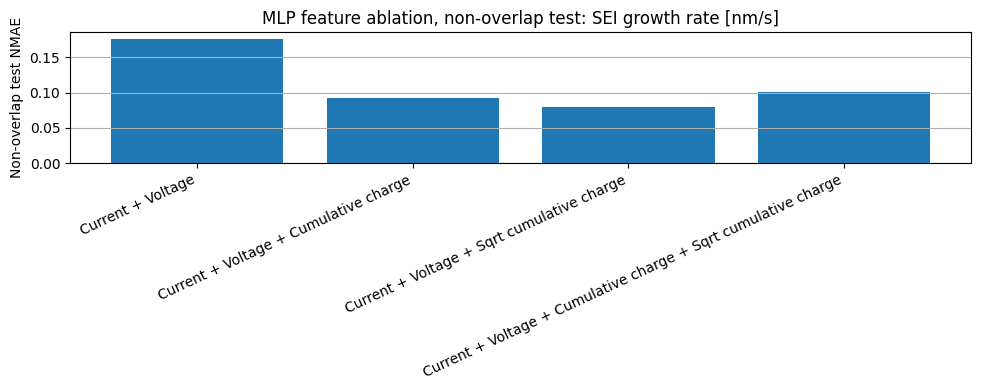

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_nonoverlap/mlp_feature_ablation_nonoverlap_NMAE_SEI_growth_rate_nm_per_s.png


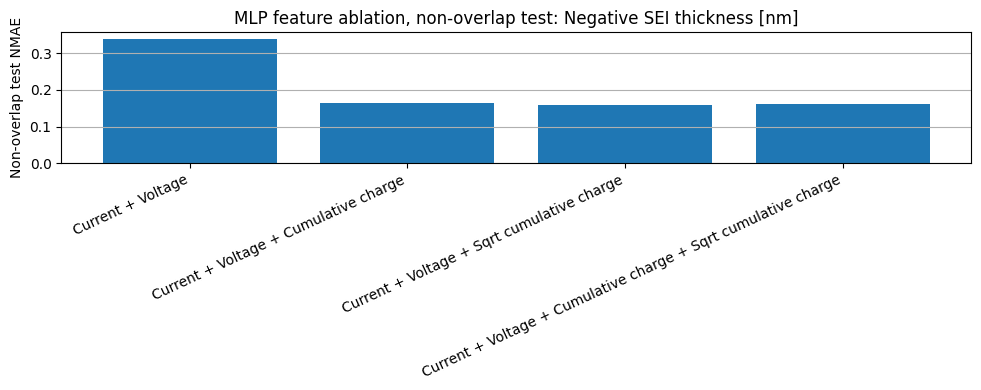

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_nonoverlap/mlp_feature_ablation_nonoverlap_NMAE_Negative_SEI_thickness_nm.png


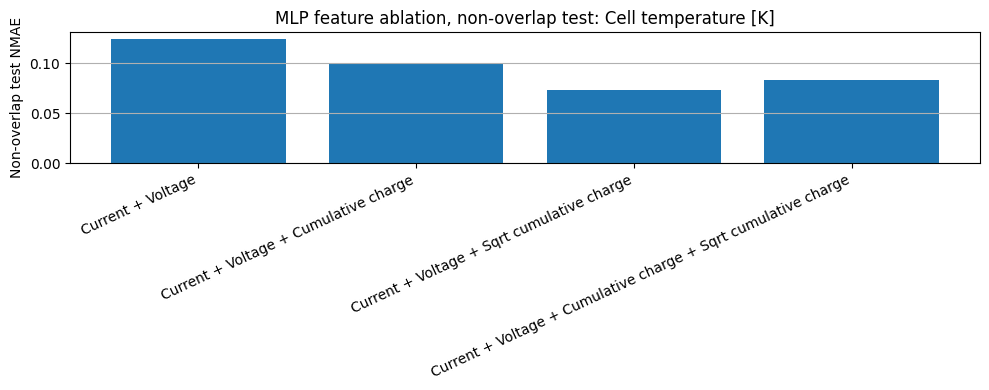

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_nonoverlap/mlp_feature_ablation_nonoverlap_NMAE_Cell_temperature_K.png


In [14]:
# Plot non-overlapping test NMAE per output

for output in output_cols:
    temp = test_metrics[test_metrics["output"] == output].copy()
    temp["feature_label"] = pd.Categorical(temp["feature_label"], categories=order, ordered=True)
    temp = temp.sort_values("feature_label")

    plt.figure(figsize=(10, 4))
    plt.bar(temp["feature_label"], temp["NMAE_std"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Non-overlap test NMAE")
    plt.title(f"MLP feature ablation, non-overlap test: {output}")
    plt.grid(axis="y")
    plt.tight_layout()

    safe_output = (
        output.replace(" ", "_")
        .replace("[", "")
        .replace("]", "")
        .replace("/", "_per_")
        .replace(".", "")
    )
    fig_path = FIGURES_DIR / f"mlp_feature_ablation_nonoverlap_NMAE_{safe_output}.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path.resolve())


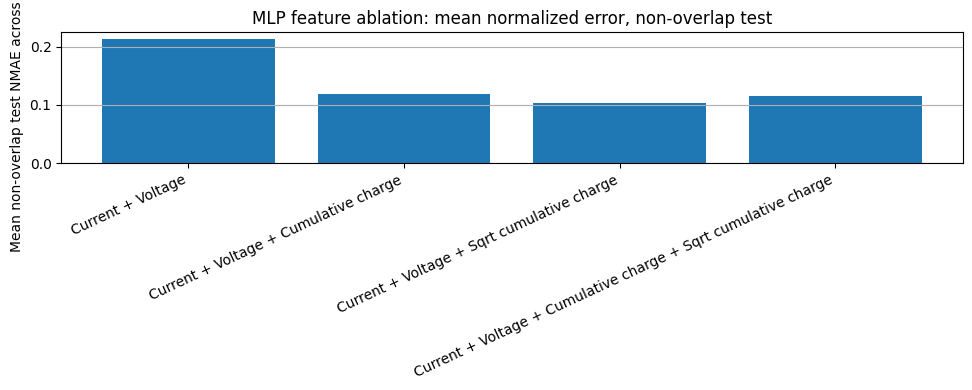

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_nonoverlap/mlp_feature_ablation_nonoverlap_mean_NMAE.png


In [15]:
# Plot mean non-overlapping test NMAE across outputs

plot_df = nmae_table.reset_index()

plt.figure(figsize=(10, 4))
plt.bar(plot_df["feature_label"], plot_df["Mean NMAE"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean non-overlap test NMAE across outputs")
plt.title("MLP feature ablation: mean normalized error, non-overlap test")
plt.grid(axis="y")
plt.tight_layout()

fig_path = FIGURES_DIR / "mlp_feature_ablation_nonoverlap_mean_NMAE.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path.resolve())


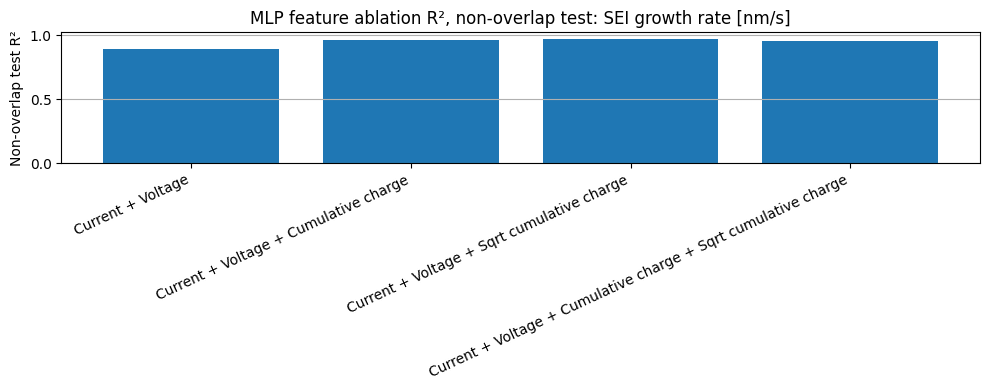

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_nonoverlap/mlp_feature_ablation_nonoverlap_R2_SEI_growth_rate_nm_per_s.png


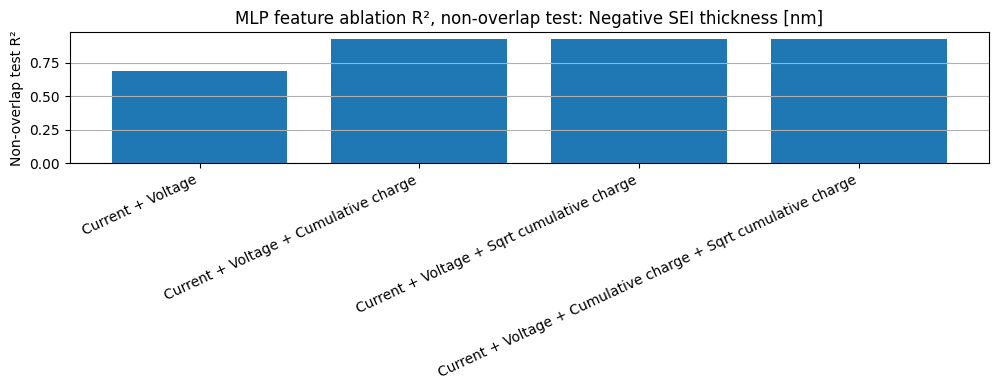

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_nonoverlap/mlp_feature_ablation_nonoverlap_R2_Negative_SEI_thickness_nm.png


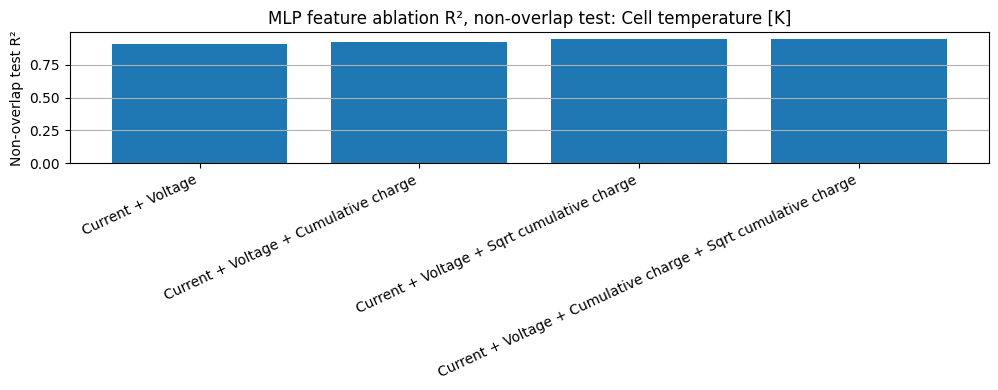

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_nonoverlap/mlp_feature_ablation_nonoverlap_R2_Cell_temperature_K.png


In [16]:
# Plot non-overlapping test R2 per output

for output in output_cols:
    temp = test_metrics[test_metrics["output"] == output].copy()
    temp["feature_label"] = pd.Categorical(temp["feature_label"], categories=order, ordered=True)
    temp = temp.sort_values("feature_label")

    plt.figure(figsize=(10, 4))
    plt.bar(temp["feature_label"], temp["R2"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Non-overlap test R²")
    plt.title(f"MLP feature ablation R², non-overlap test: {output}")
    plt.grid(axis="y")
    plt.tight_layout()

    safe_output = (
        output.replace(" ", "_")
        .replace("[", "")
        .replace("]", "")
        .replace("/", "_per_")
        .replace(".", "")
    )
    fig_path = FIGURES_DIR / f"mlp_feature_ablation_nonoverlap_R2_{safe_output}.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path.resolve())


## Horizon-wise normalized MAE comparison

This plot shows whether one feature set becomes worse at later forecast steps under non-overlapping test evaluation.


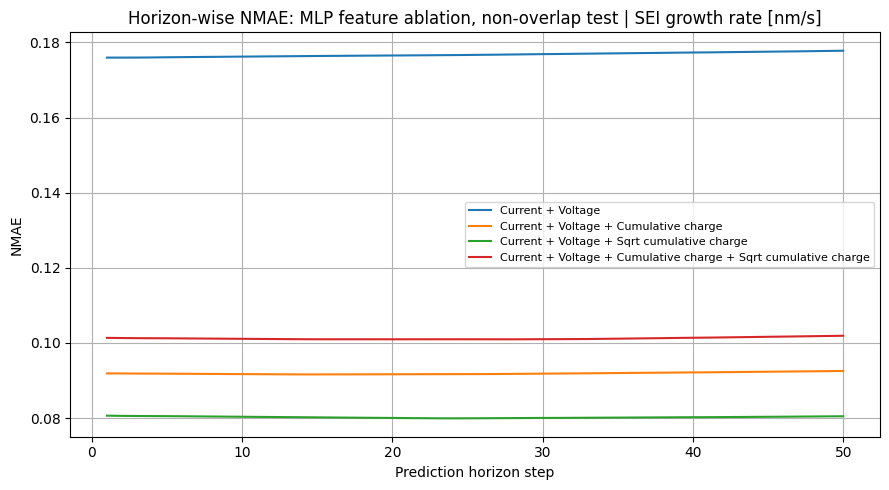

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_nonoverlap/mlp_feature_ablation_nonoverlap_horizon_NMAE_SEI_growth_rate_nm_per_s.png


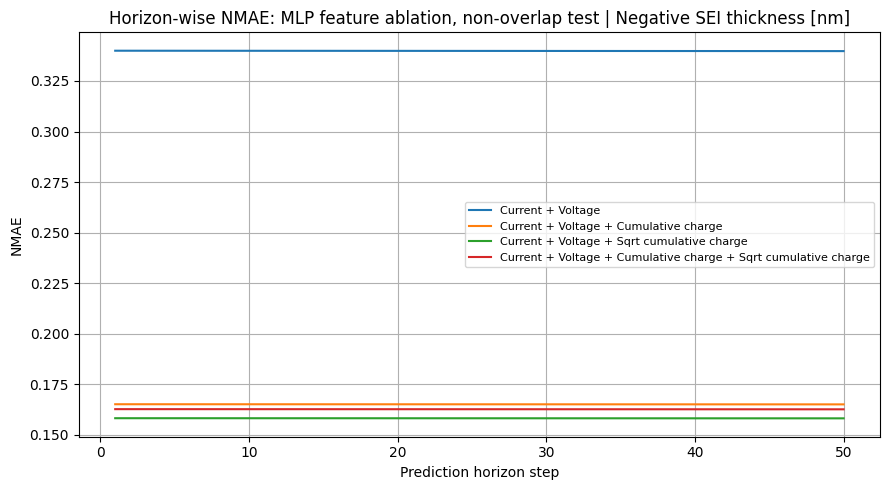

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_nonoverlap/mlp_feature_ablation_nonoverlap_horizon_NMAE_Negative_SEI_thickness_nm.png


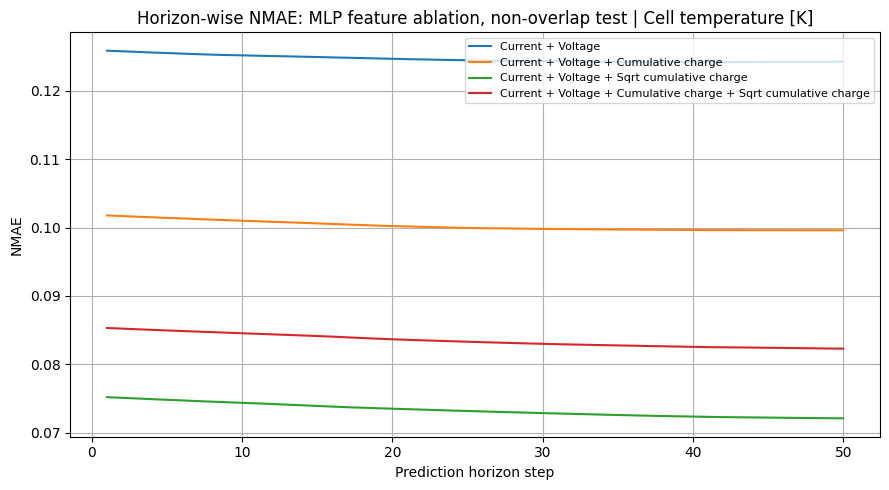

Saved: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/figures_nonoverlap/mlp_feature_ablation_nonoverlap_horizon_NMAE_Cell_temperature_K.png


In [17]:
for output in output_cols:
    plt.figure(figsize=(9, 5))

    for feature_label in order:
        temp = combined_horizon_nmae[
            (combined_horizon_nmae["output"] == output)
            & (combined_horizon_nmae["feature_label"] == feature_label)
            & (combined_horizon_nmae["split"] == SELECTED_SPLIT)
        ]
        plt.plot(temp["horizon_step"], temp["NMAE_std"], label=feature_label)

    plt.xlabel("Prediction horizon step")
    plt.ylabel("NMAE")
    plt.title(f"Horizon-wise NMAE: MLP feature ablation, non-overlap test | {output}")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.tight_layout()

    safe_output = (
        output.replace(" ", "_")
        .replace("[", "")
        .replace("]", "")
        .replace("/", "_per_")
        .replace(".", "")
    )
    fig_path = FIGURES_DIR / f"mlp_feature_ablation_nonoverlap_horizon_NMAE_{safe_output}.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved:", fig_path.resolve())


## Physical violation summary

This table checks whether the non-overlapping test predictions produce negative SEI growth rate, negative SEI thickness, or negative Kelvin temperature after inverse scaling.


In [18]:
violation_summary = combined_violations.pivot_table(
    index="feature_label",
    columns="output",
    values="negative_percent",
    aggfunc="mean",
)

violation_summary = violation_summary.loc[order]

violation_summary_path = RESULTS_DIR / f"mlp_feature_ablation_nonoverlap_L{INPUT_LENGTH}_H{PREDICTION_HORIZON}_S{STRIDE}_violation_percent_table.csv"
violation_summary.to_csv(violation_summary_path)

print("Saved non-overlap violation percent table:", violation_summary_path.resolve())
violation_summary


Saved non-overlap violation percent table: /Users/bikeshshr/Documents/battery_seq2seq_surrogate/results_nonoverlap/mlp_feature_ablation_nonoverlap_L50_H50_S5_violation_percent_table.csv


output,Cell temperature [K],Negative SEI thickness [nm],SEI growth rate [nm/s]
feature_label,,,
Current + Voltage,0.0,0.020392,6.339723
Current + Voltage + Cumulative charge,0.0,0.020392,6.907423
Current + Voltage + Sqrt cumulative charge,0.0,0.020392,11.472675
Current + Voltage + Cumulative charge + Sqrt cumulative charge,0.0,0.020392,9.576264
